# Trabajo Práctico 3 - Visión por Computadora

### Alumnos:
* BETTIG, Santiago Federico
* DIEGUEZ, Manuel

### Consigna
Encontrar el logotipo de la gaseosa dentro de las imágenes provistas a partir del template

In [5]:
# Importamos las bibliotecas que vamos a utilizar
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os
import supervision as sv

#### Parte 1
Obtener una detección del logo en cada imagen sin falsos positivos

In [ ]:
# Vamos a crear una función la cual reciba el template y la imagen a comparar y nos 
# devuelva el resultado de la detección
def getSingleMatch(cv_template, grey_image):
    # Abrimos el template en escala de grises, le aplicamos
    # un filtro para reducir ruido y luego canny para quedarnos solo
    # con los bordes
    img_temp = cv.GaussianBlur(cv_template, (3,3), 0)
    temp_edges = cv.Canny(img_temp, 160, 300)

    # Obtengo las dimensiones del template
    w_temp, h_temp = img_temp.shape[::-1]

    # Creo variables para guardar los mejores resultados de la exploración
    best_score = -1
    best_loc = None
    best_r = None
    r_count = 0

    # Por cada iteración voy a reescalar la imagen original, aplicar
    # un filtro blur seguido de Canny para quedarme solo con los bordes.
    for r in np.linspace(0.2, 5.0, 80):
        # Aplico el resize a la imagen en escala de grises
        resized_gray = cv.resize(grey_image, None, fx=r, fy=r, interpolation=cv.INTER_AREA if r < 1 else cv.INTER_LINEAR)
        r_count += 1

        # Si la imagen quedó mas chica que el template, no la comparo
        if resized_gray.shape[0] < h_temp or resized_gray.shape[1] < w_temp:
            continue  
        else:
            # De lo contrario, aplico el filtrado para tener una mejor 
            # detección. 
            resized_gray    = cv.GaussianBlur(resized_gray, (3,3), 0)
            resized_edges   = cv.Canny(resized_gray, 160, 360)

            # Aplico el matchTemplate y me quedo con los mejores valores
            res = cv.matchTemplate(resized_edges, temp_edges, cv.TM_CCOEFF_NORMED)
            _, max_val, _, max_loc = cv.minMaxLoc(res)

            # Si se desea imprimir cada una de las iteraciones, debe fijarse la variable
            # PRINT_DEBUG_IMAGES = True
            if PRINT_DEBUG_IMAGES:
                # Mapeo de vuelta a coordenadas de la imagen ORIGINAL (sin reescalar)
                top_left = (int(max_loc[0]/r), int(max_loc[1]/r))
                bottom_right = (int((max_loc[0]+w_temp)/r), int((max_loc[1]+h_temp)/r))
                
                img_rgb = cv.cvtColor(grey_image, cv.COLOR_BGR2RGB)
                cv.rectangle(img_rgb, top_left, bottom_right, (0,255,0), 2)

                # Resultado de coincidencia
                plt.figure()
                plt.subplot(121),plt.imshow(resized_edges, cmap = 'gray')
                plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
                # Imagen original con recuadros
                plt.subplot(122),plt.imshow(img_rgb)
                plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
                plt.show()
                print(f"run: [",r_count,"]: ", max_val)
            
            # Me fijo si la iteración superó a la anterior. De ser así, la guardo
            # como mejor valor.
            if max_val > best_score:
                best_score, best_loc, best_r = max_val, max_loc, r

    return best_score, best_loc, best_r

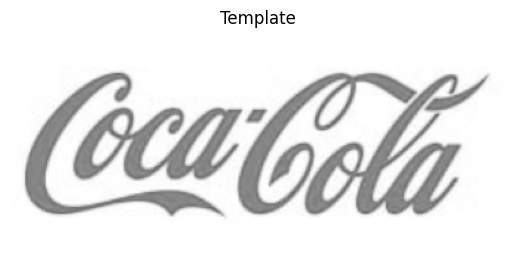

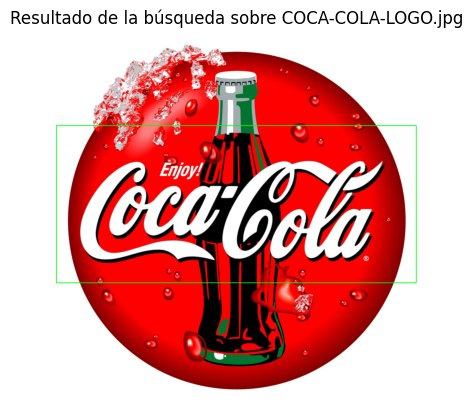

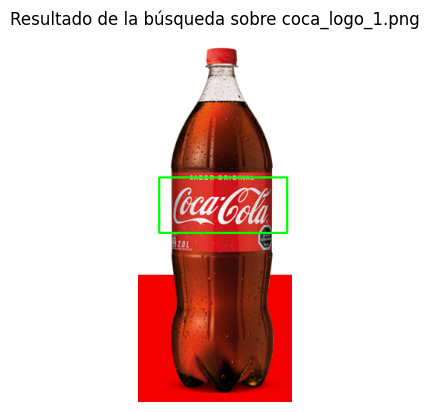

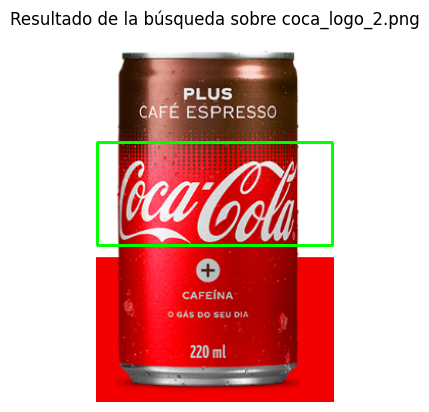

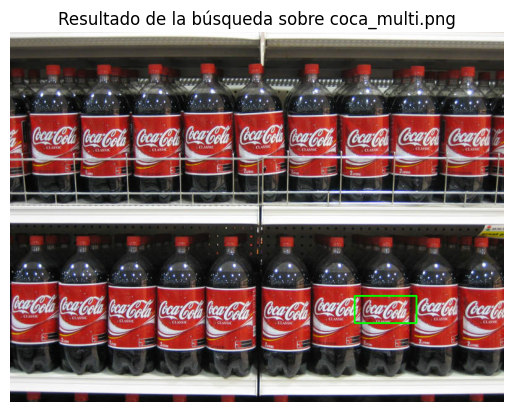

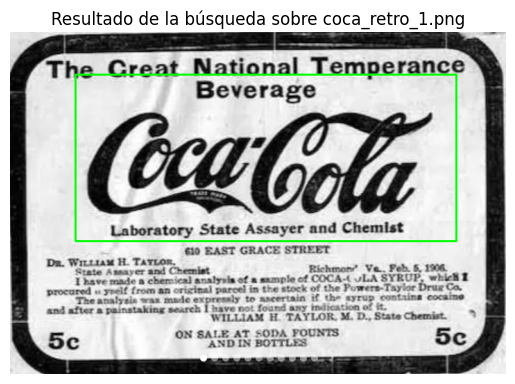

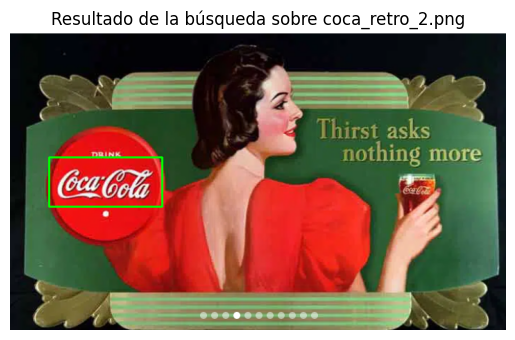

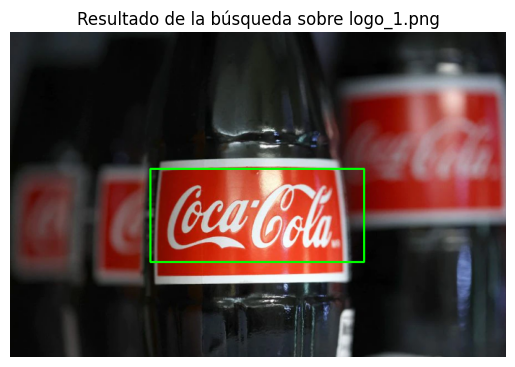

In [94]:
# Definimos el path en donde va a estar el template y la carpeta
# con todas nuestras imagenes
TEMPLATE_PATH   = './template/pattern.png'
IMAGES_PATH     = './images'
PRINT_DEBUG_IMAGES = False

# Abrimos el template:
img_temp = cv.imread(TEMPLATE_PATH, cv.IMREAD_GRAYSCALE)
# Nos aseguramos de que se haya abierto correctamente
plt.imshow(cv.cvtColor(img_temp, cv.COLOR_BGR2RGB))
plt.title('Template')
plt.axis("off");
plt.show()

for image_filename in os.listdir(IMAGES_PATH):
    # if image_filename == 'coca_multi.png':
    # Obtenemos el path de la imagen y pasamos a abrirla
    img_path        = os.path.join(IMAGES_PATH, image_filename)
    img_gray        = cv.imread(img_path, cv.IMREAD_GRAYSCALE) 
    _, thresh_img   = cv.threshold(img_gray, 175, 255, cv.THRESH_BINARY)

    img_rgb     = cv.imread(img_path)

    # Aplicamos la búsqueda sobre la imagen y obtenemos 
    # el resultado
    best_score, best_loc, best_r = getSingleMatch(img_temp, thresh_img)

    # Obtengo las coordenadas de cuadro sobre la imagen original
    # Obtengo las dimensiones del template
    w_temp, h_temp = img_temp.shape[::-1]
    top_left = (int(best_loc[0]/best_r), int(best_loc[1]/best_r))
    bottom_right = (int((best_loc[0]+w_temp)/best_r), int((best_loc[1]+h_temp)/best_r))

    # Dibujo la caja que señalará la imagen
    cv.rectangle(img_rgb, top_left, bottom_right, (0,255,0), 2)

    # Imprimo los resultados
    plt.imshow(cv.cvtColor(img_rgb, cv.COLOR_BGR2RGB))
    plt.title('Resultado de la búsqueda sobre ' + image_filename)
    plt.axis("off");
    plt.show()
